In [2]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("CPU threads:", tf.config.threading.get_inter_op_parallelism_threads())

TF version: 2.19.0
GPU available: []
CPU threads: 0


In [3]:
import os

base_path = "/kaggle/input/"

for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:
        for f in files[:3]:
            print(f"  {indent}{f}")

/
datasets/
  rafisongram/
    ras-compound-character-dataset/
      RAS-Compound-character-dataset/
        test/
          7/
          47/
          17/
          81/
          19/
          22/
          2/
          35/
          92/
          50/
          23/
          87/
          10/
          5/
          61/
          36/
          109/
          20/
          45/
          60/
          27/
          64/
          41/
          89/
          39/
          32/
          98/
          25/
          42/
          52/
          75/
          8/
          38/
          12/
          94/
          55/
          105/
          49/
          112/
          31/
          62/
          114/
          53/
          101/
          70/
          34/
          18/
          79/
          85/
          88/
          65/
          67/
          106/
          78/
          28/
          66/
          56/
          72/
          16/
          113/
          13/
          99/
          108/

In [5]:
import os

# ── After running Cell 2, update this to your exact dataset folder name ──
DATA_DIR   = "/kaggle/input/datasets/rafisongram/ras-compound-character-dataset/RAS-Compound-character-dataset"   # <-- change this
TRAIN_DIR  = f"{DATA_DIR}/train"
TEST_DIR   = f"{DATA_DIR}/test"

IMG_SIZE    = (96, 96)   # smaller = faster on CPU
BATCH_SIZE  = 16
EPOCHS_HEAD = 5
EPOCHS_FINE = 10

print("Train dir exists:", os.path.exists(TRAIN_DIR))
print("Test dir exists: ", os.path.exists(TEST_DIR))

Train dir exists: True
Test dir exists:  True


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=False,  # characters are direction-sensitive
)

test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    subset="training",
    seed=42,
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    subset="validation",
    seed=42,
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    shuffle=False,
)

NUM_CLASSES = train_gen.num_classes
print(f"Total classes : {NUM_CLASSES}")
print(f"Train samples : {train_gen.samples}")
print(f"Val samples   : {val_gen.samples}")
print(f"Test samples  : {test_gen.samples}")

Found 5662 images belonging to 119 classes.
Found 1358 images belonging to 119 classes.
Found 816 images belonging to 119 classes.
Total classes : 119
Train samples : 5662
Val samples   : 1358
Test samples  : 816


In [9]:
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def build_model(num_classes):
    base = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMG_SIZE, 3),
    )
    base.trainable = False  # freeze base for Phase 1

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = preprocess_input(inputs)       # scales pixels to [-1, 1]
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)
    return model, base

model, base_model = build_model(NUM_CLASSES)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 119)            │        15,351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,442,423 (9.32 MB)

 Trainable params: 181,879 (710.46 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_head = [
    tf.keras.callbacks.EarlyStopping(
        patience=3, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5, patience=2, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_head.keras",
        save_best_only=True, verbose=1
    ),
]

print("=" * 50)
print("Phase 1: Training head only (base frozen)")
print("=" * 50)

history1 = model.fit(
    train_gen,
    epochs=EPOCHS_HEAD,
    validation_data=val_gen,
    callbacks=callbacks_head,
)

Phase 1: Training head only (base frozen)
Epoch 1/5
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.3016 - loss: 3.3102
Epoch 1: val_loss improved from None to 0.48068, saving model to /kaggle/working/best_head.keras

Epoch 1: finished saving model to /kaggle/working/best_head.keras
354/354 ━━━━━━━━━━━━━━━━━━━━ 69s 176ms/step - accuracy: 0.5079 - loss: 2.1549 - val_accuracy: 0.8976 - val_loss: 0.4807 - learning_rate: 0.0010
Epoch 2/5
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8015 - loss: 0.7243
Epoch 2: val_loss improved from 0.48068 to 0.18695, saving model to /kaggle/working/best_head.keras

Epoch 2: finished saving model to /kaggle/working/best_head.keras
354/354 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accuracy: 0.8144 - loss: 0.6622 - val_accuracy: 0.9507 - val_loss: 0.1869 - learning_rate: 0.0010
Epoch 3/5
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8622 - loss: 0.4942
Epoch 3: val_loss improved from 0.18695 to 0.15628, saving model to /kaggle/work

In [11]:
# Unfreeze top 20 layers of MobileNetV2
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

print(f"Trainable layers: {sum(1 for l in model.layers if l.trainable)}")

# Recompile with very low LR — critical to not destroy ImageNet weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_ft = [
    tf.keras.callbacks.EarlyStopping(
        patience=4, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5, patience=3, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_finetune.keras",
        save_best_only=True, verbose=1
    ),
]

print("=" * 50)
print("Phase 2: Fine-tuning top 20 layers")
print("=" * 50)

history2 = model.fit(
    train_gen,
    epochs=EPOCHS_FINE,
    validation_data=val_gen,
    callbacks=callbacks_ft,
)

Trainable layers: 7
Phase 2: Fine-tuning top 20 layers
Epoch 1/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5319 - loss: 1.8283
Epoch 1: val_loss improved from None to 0.37600, saving model to /kaggle/working/best_finetune.keras

Epoch 1: finished saving model to /kaggle/working/best_finetune.keras
354/354 ━━━━━━━━━━━━━━━━━━━━ 55s 131ms/step - accuracy: 0.5772 - loss: 1.5934 - val_accuracy: 0.8851 - val_loss: 0.3760 - learning_rate: 1.0000e-05
Epoch 2/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.6838 - loss: 1.1483
Epoch 2: val_loss improved from 0.37600 to 0.23616, saving model to /kaggle/working/best_finetune.keras

Epoch 2: finished saving model to /kaggle/working/best_finetune.keras
354/354 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.6915 - loss: 1.1023 - val_accuracy: 0.9323 - val_loss: 0.2362 - learning_rate: 1.0000e-05
Epoch 3/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.7348 - loss: 0.8962
Epoch 3: val_loss improved from 0.23616

Final Test Set Evaluation
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.8750 - loss: 0.4221

Test Accuracy : 87.50%
Test Loss     : 0.4221


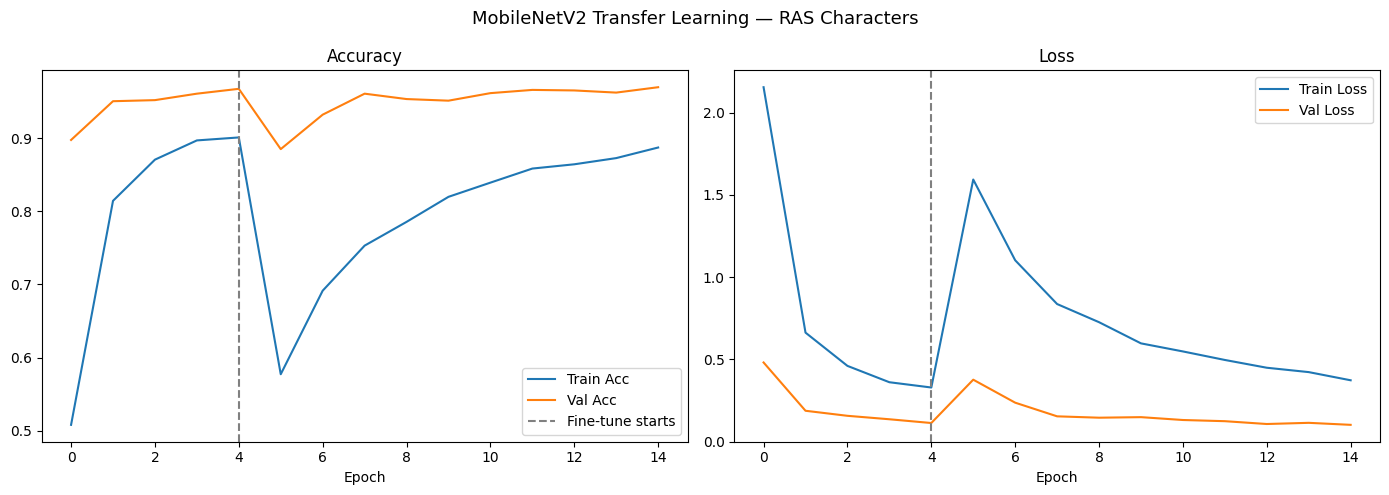

Plot saved → /kaggle/working/training_curves.png


In [12]:
import matplotlib.pyplot as plt

# ── Test set evaluation ──
print("=" * 50)
print("Final Test Set Evaluation")
print("=" * 50)
loss, acc = model.evaluate(test_gen, verbose=1)
print(f"\nTest Accuracy : {acc*100:.2f}%")
print(f"Test Loss     : {loss:.4f}")

# ── Training curves ──
def plot_history(h1, h2):
    a1  = h1.history["accuracy"]
    a2  = h2.history["accuracy"]
    va1 = h1.history["val_accuracy"]
    va2 = h2.history["val_accuracy"]
    l1  = h1.history["loss"]
    l2  = h2.history["loss"]
    vl1 = h1.history["val_loss"]
    vl2 = h2.history["val_loss"]

    acc_all  = a1  + a2
    val_all  = va1 + va2
    loss_all = l1  + l2
    vloss_all= vl1 + vl2
    split    = len(a1)
    epochs   = range(len(acc_all))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, acc_all,  label="Train Acc")
    ax1.plot(epochs, val_all,  label="Val Acc")
    ax1.axvline(split - 1, color="grey", linestyle="--", label="Fine-tune starts")
    ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend()

    ax2.plot(epochs, loss_all,  label="Train Loss")
    ax2.plot(epochs, vloss_all, label="Val Loss")
    ax2.axvline(split - 1, color="grey", linestyle="--")
    ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend()

    plt.suptitle("MobileNetV2 Transfer Learning — RAS Characters", fontsize=13)
    plt.tight_layout()
    plt.savefig("/kaggle/working/training_curves.png", dpi=150)
    plt.show()
    print("Plot saved → /kaggle/working/training_curves.png")

plot_history(history1, history2)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

class_names = list(train_gen.class_indices.keys())
try:
    mapping_df = pd.read_csv("class_mapping.csv")
    id_to_char = dict(zip(mapping_df["class_id"].astype(str), mapping_df["bengali_character"]))
    display_names = [id_to_char[c] for c in class_names]
except FileNotFoundError:
    display_names = class_names

y_true = test_gen.classes
y_pred = model.predict(test_gen, verbose=1).argmax(axis=1)

test_acc = (y_true == y_pred).mean()
cer = 1 - test_acc  # single-character samples: CER == top-1 error rate
print(f"Test Accuracy: {test_acc:.4f}")
print(f"CER          : {cer:.4f}\n")
print(classification_report(y_true, y_pred, target_names=display_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", xticklabels=display_names, yticklabels=display_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix (CER: {cer:.4f})")
plt.tight_layout()
plt.show()

Classes: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99']


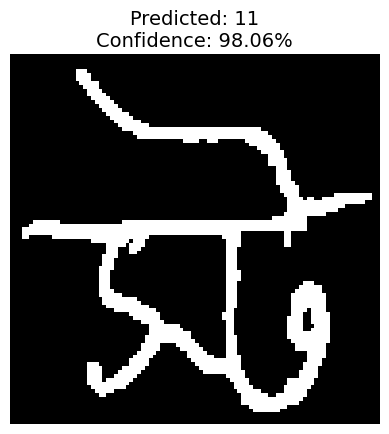

Predicted class : 11
Confidence      : 98.06%


('11', np.float32(98.06246))

In [19]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Get class names from training generator
class_names = list(train_gen.class_indices.keys())
print("Classes:", class_names)

def predict_image(img_path):
    # Load and preprocess
    img = image.load_img(img_path, target_size=IMG_SIZE, color_mode="rgb")
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

    # Predict
    predictions = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    # Show image + result
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}%", fontsize=14)
    plt.show()

    print(f"Predicted class : {predicted_class}")
    print(f"Confidence      : {confidence:.2f}%")
    return predicted_class, confidence

# ── Test with one image ──
# Replace with any image path from your test folder
sample_path = "/kaggle/input/datasets/rafisongram/ras-compound-character-dataset/RAS-Compound-character-dataset/test/11/12.png"
predict_image(sample_path)

In [14]:
# Save in both formats
model.save("/kaggle/working/ras_mobilenet_final.keras")

# Also export as SavedModel (easier to deploy)
model.export("/kaggle/working/ras_savedmodel")

print("Files saved to /kaggle/working/:")
for f in os.listdir("/kaggle/working/"):
    print(f"  {f}")
print("\nDownload from the Output tab on the right ✓")

INFO:tensorflow:Assets written to: /kaggle/working/ras_savedmodel/assets


INFO:tensorflow:Assets written to: /kaggle/working/ras_savedmodel/assets


Saved artifact at '/kaggle/working/ras_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor_471')
Output Type:
  TensorSpec(shape=(None, 119), dtype=tf.float32, name=None)
Captures:
  139329950184272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139329950183888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139329950186000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139329950185616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139329950185808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139329950181968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139329950184080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139329950185424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139329950185232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139329950186960: TensorSpec(shape=(), dtype=tf.resource, name=None